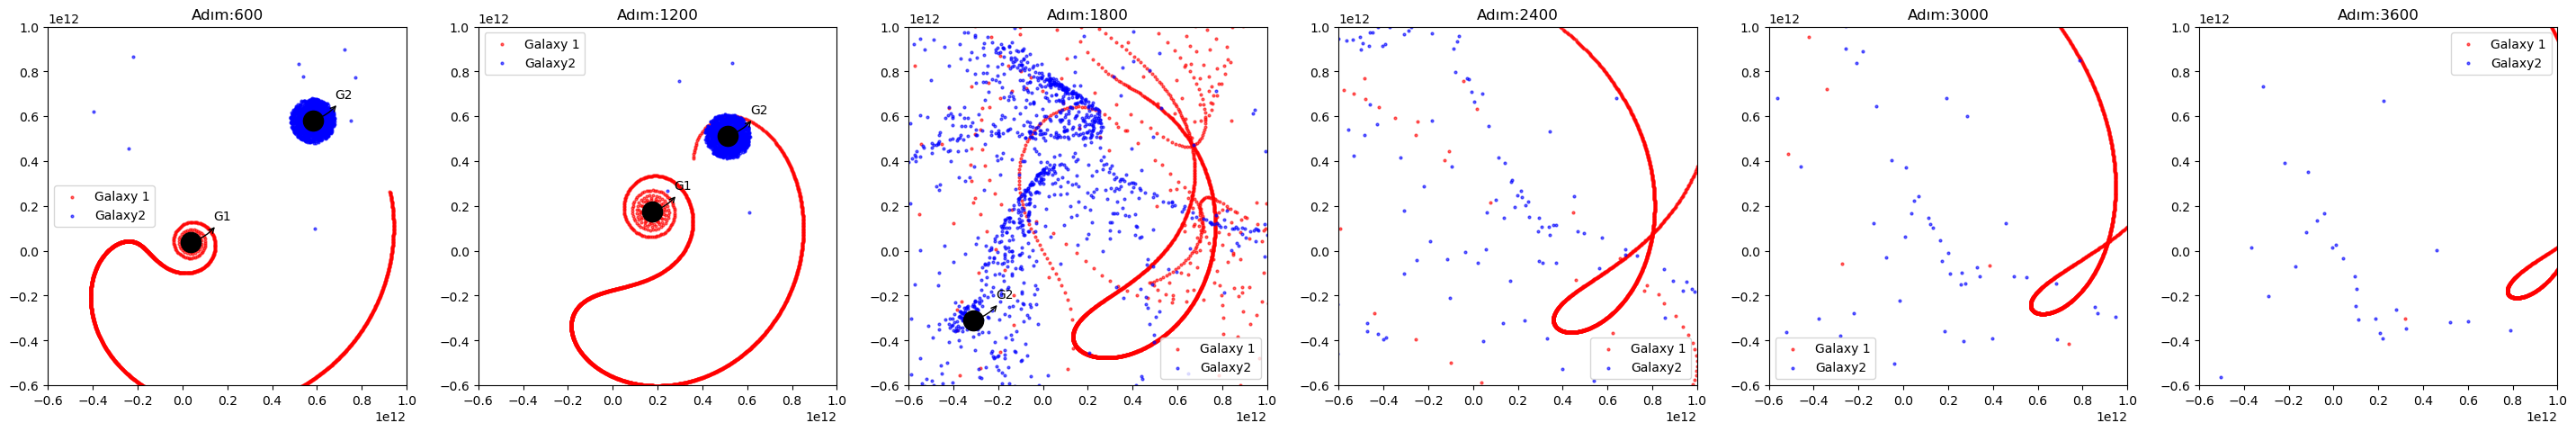

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

G=6.67e-11
M1=1.0e30
vg1=np.array([0.0,0.0])
xy_1=np.array([0,0])*1.0e11

M2=2.0e30
xy_2=np.array([6,6])*1.0e11
vg2=np.array([0.0,0.0])

N=2000
#for the first galaxy
radius1=np.linspace(0,10,N)
angle1=np.linspace(0,2*np.pi,N)

stars_x1=radius1*np.cos(angle1)*1.0e11
stars_y1=radius1*np.sin(angle1)*1.0e11
d1_g1=np.sqrt(stars_x1**2+stars_y1**2)
r1_g1=np.stack((stars_x1,stars_y1),axis=1)
    
#for the second galaxy
radius2=np.random.rand(N)
angle2=np.linspace(0,2*np.pi,N)

stars_x2=xy_2[0]+(radius2*np.cos(angle2))*1.0e11
stars_y2=xy_2[1]+(radius2*np.sin(angle2))*1.0e11
d2_g2=np.sqrt((stars_x2-xy_2[0])**2+(stars_y2-xy_2[1])**2)
r2_g2=np.stack((stars_x2-xy_2[0],stars_y2-xy_2[1]),axis=1)
#r is vector d is scalar to facilitate the computing

with np.errstate(divide="ignore",invalid="ignore"):
    velocities1=np.sqrt(G*M1/d1_g1)
    v1=np.stack((-velocities1*(stars_y1-xy_1[1])/d1_g1,velocities1*(stars_x1-xy_1[0])/d1_g1),axis=1)#vectoral sum
    
    velocities2=np.sqrt(G*M2/d2_g2)
    v2=np.stack((-velocities2*(stars_y2-xy_2[1])/d2_g2,velocities2*(stars_x2-xy_2[0])/d2_g2),axis=1)#vectoral sum

n=6
fig,axes=plt.subplots(1,n,figsize=(36,36))
steps=3600
snapshot=steps/n
current=0
#ax[0]-->first ax[1]--->2nd graph and so on

dt=3600*11
e=1.0e-11
for i in range(1,steps+1):    
    with np.errstate(divide="ignore",invalid="ignore"):
        d12=xy_2-xy_1
        r2_g1=r2_g2+d12
        r1_g2=r1_g1-d12
    #calculating the acceleration by G1 and G2 for stars
        a1=-G*M1*r1_g1/(np.sum(r1_g1**2,axis=1)**1.5+e)[:,None] + -G*M2*r1_g2/(np.sum(r1_g2**2,axis=1)**1.5+e)[:,None]
        a2=-G*M1*r2_g1/(np.sum(r2_g1**2,axis=1)**1.5+e)[:,None] + -G*M2*r2_g2/(np.sum(r2_g2**2,axis=1)**1.5+e)[:,None]

        a_g1=G*M2*d12/(np.sum(d12**2)**1.5+e)
        a_g2=-G*M1*d12/(np.sum(d12**2)**1.5+e)

    v1+=a1*dt
    r1_g1+= (v1-vg1)*dt

    v2=v2+a2*dt
    r2_g2+=(v2-vg2)*dt

    vg1+=a_g1*dt
    xy_1=xy_1+vg1*dt

    vg2+=a_g2*dt
    xy_2=xy_2+vg2*dt
    
    if i%snapshot==0 and current<n:
        ax=axes[current]
        ax.plot(xy_1[0],xy_1[1],"ok",markersize=16)
        ax.annotate("G1",xy=xy_1,xytext=xy_1+1.0e11,arrowprops=dict(arrowstyle="<-",
                            connectionstyle="arc3,rad=-0.2"))
        ax.scatter(r1_g1[:,0]+xy_1[0],r1_g1[:,1]+xy_1[1],c="red",label="Galaxy 1",alpha=0.6,s=4)

        ax.plot(xy_2[0],xy_2[1],"ok",markersize=16)
        ax.annotate("G2",xy=xy_2,xytext=xy_2+1.0e11,arrowprops=dict(arrowstyle="<-",
                            connectionstyle="arc3,rad=-0.2"))
        ax.scatter(r2_g2[:,0]+xy_2[0],r2_g2[:,1]+xy_2[1],c="blue",label="Galaxy2",alpha=0.6,s=4)
        
        ax.legend()
        ax.set_title(f"Adım:{i}")
        ax.set_xlim(-6.0e11,1.0e12)
        ax.set_ylim(-6.0e11,1.0e12)
        ax.set_aspect("equal")
        current+=1

plt.savefig("Galaxy_Collision",dpi=300)
plt.show()